In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("./insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## EDA

In [ ]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Axes: ylabel='count'>

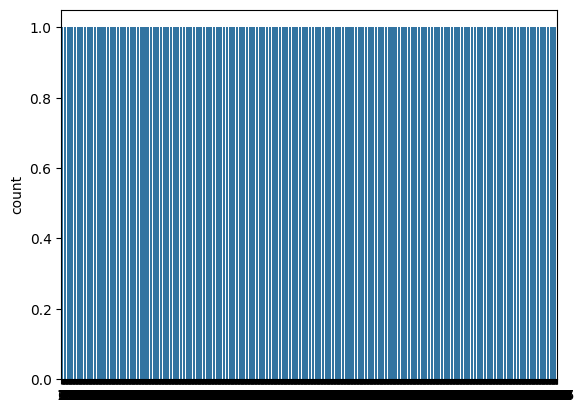

In [14]:
df.columns
sns.countplot(df.children)

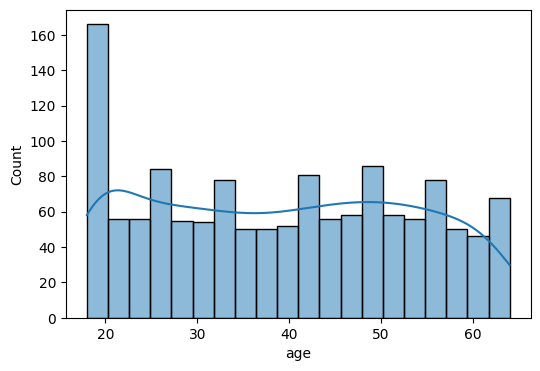

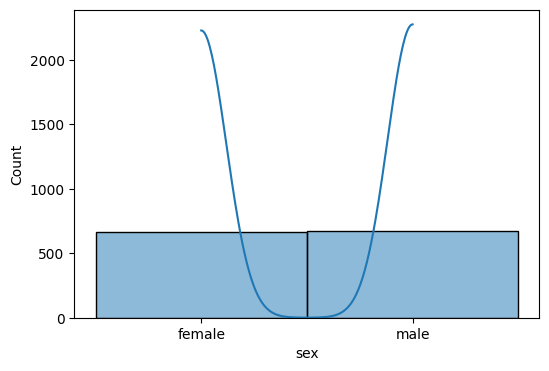

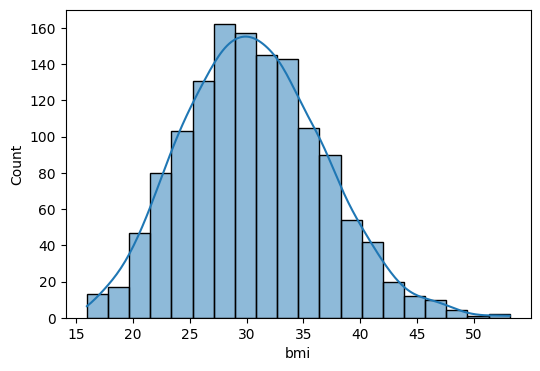

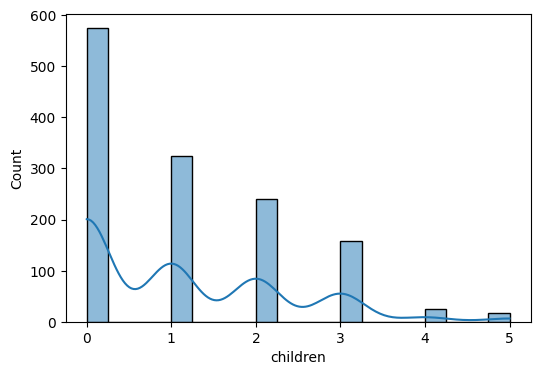

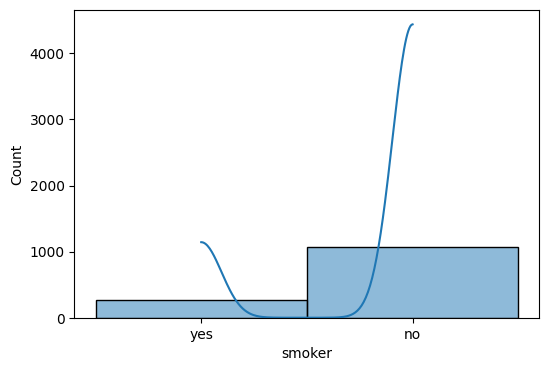

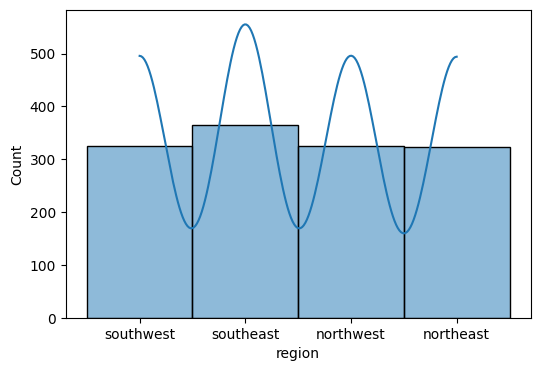

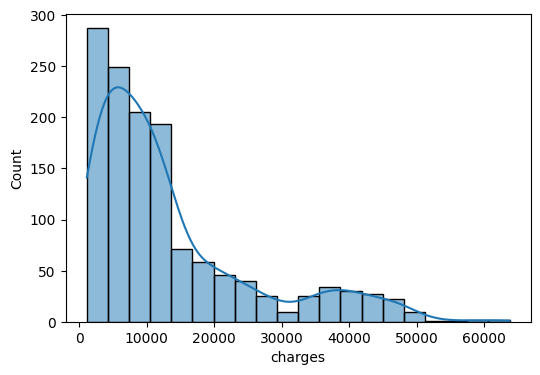

In [18]:
numeric_columns =['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges' ]
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='sex', ylabel='count'>

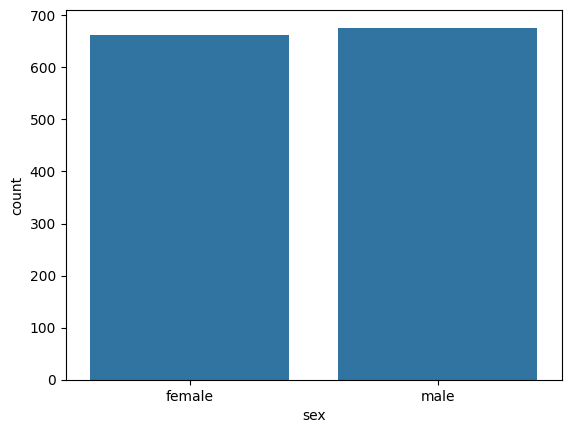

In [20]:
sns.countplot(x =df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

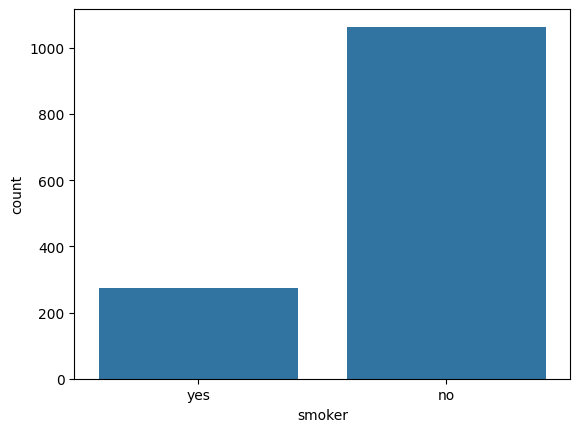

In [21]:
sns.countplot(x =df['smoker'])

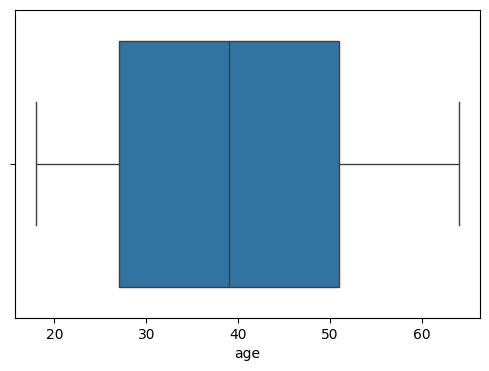

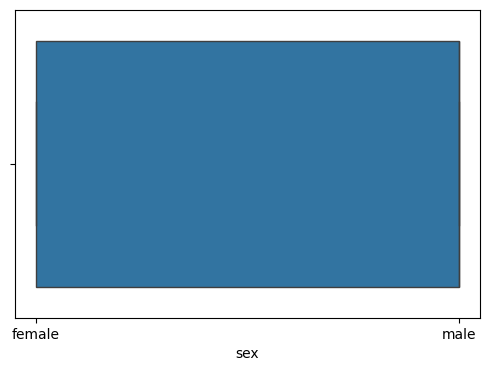

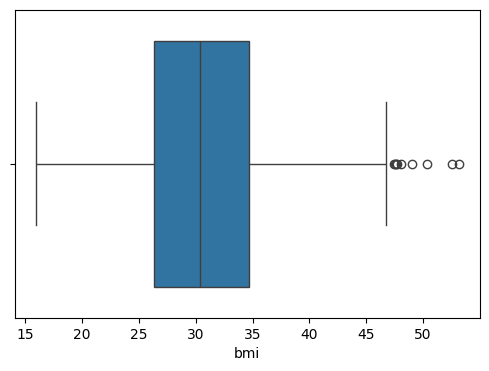

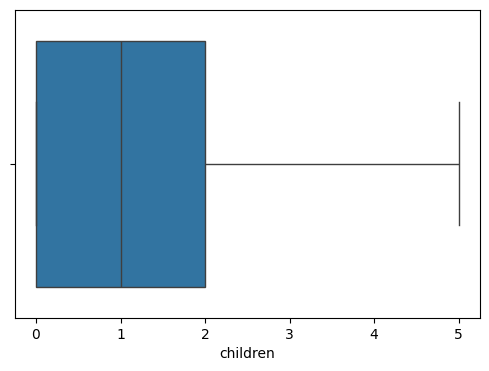

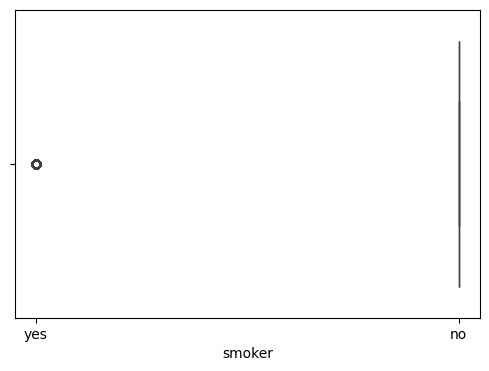

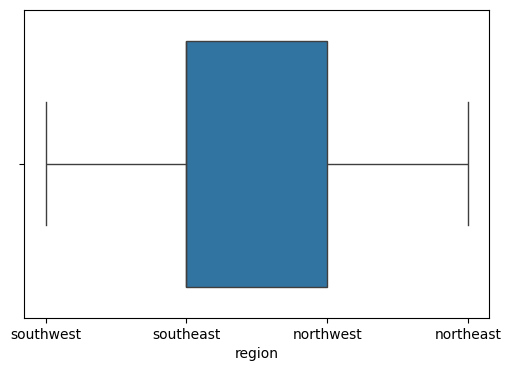

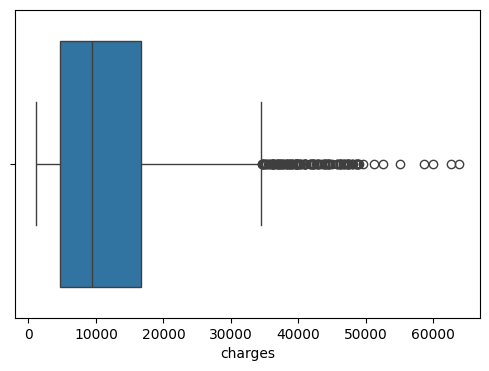

In [22]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

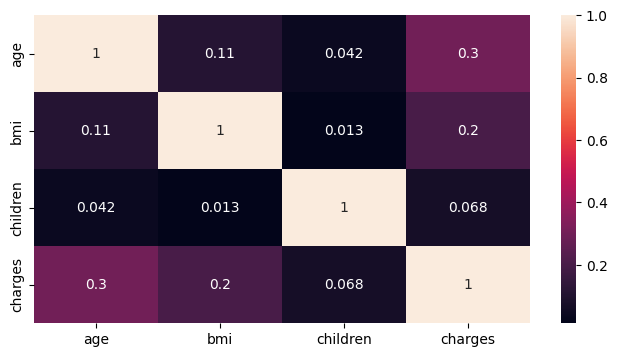

In [25]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning and processing

In [31]:
df.isnull().sum()
df_cleaned = df.copy()
df_cleaned.head()
df_cleaned.drop_duplicates(inplace = True)


In [32]:
df_cleaned.shape
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [34]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [35]:
df_cleaned["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [36]:
df_cleaned["sex"] = df_cleaned["sex"].map({"male":0,"female":1})

In [ ]:
df_cleaned.head()
df_cleaned.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [39]:
df_cleaned["smoker"].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [40]:
df_cleaned["smoker"]=df_cleaned["smoker"].map({"no":0,"yes":1})

In [ ]:
df_cleaned.head()



,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [42]:
df_cleaned.rename(columns={"smoker":"is_smoker","sex":"is_female"},inplace=True)

In [43]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [44]:
df_cleaned["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [49]:
df_cleaned = df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


# Feature Engineering and Extraction

In [50]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned["bmi"],
    bins = [0,18.5,24.9,29.9,float("inf")],
    labels=["underweight","healthy","overweight","obese"]
 )

In [51]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,overweight
1,18,0,33,1,0,1725,0,0,1,0,obese
2,28,0,33,3,0,4449,0,0,1,0,obese
3,33,0,22,0,0,21984,0,1,0,0,healthy
4,32,0,28,0,0,3866,0,1,0,0,overweight


In [52]:
df_cleaned["age_group"] = pd.cut(
    df_cleaned["age"],
    bins=[0,18,30,60,float("inf")],
    labels=["kid","young","adult","old"]

)

In [53]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category,age_group
0,19,1,27,0,1,16884,0,0,0,1,overweight,young
1,18,0,33,1,0,1725,0,0,1,0,obese,kid
2,28,0,33,3,0,4449,0,0,1,0,obese,young
3,33,0,22,0,0,21984,0,1,0,0,healthy,adult
4,32,0,28,0,0,3866,0,1,0,0,overweight,adult


In [54]:
df_cleaned = pd.get_dummies(df_cleaned,columns=["bmi_category","age_group"])
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese,age_group_kid,age_group_young,age_group_adult,age_group_old
0,19,1,27,0,1,16884,0,0,0,1,False,False,True,False,False,True,False,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,False,True,True,False,False,False
2,28,0,33,3,0,4449,0,0,1,0,False,False,False,True,False,True,False,False
3,33,0,22,0,0,21984,0,1,0,0,False,True,False,False,False,False,True,False
4,32,0,28,0,0,3866,0,1,0,0,False,False,True,False,False,False,True,False


In [55]:
df_cleaned = df_cleaned.astype(int)

In [56]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese,age_group_kid,age_group_young,age_group_adult,age_group_old
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0,0,1,0,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1,1,0,0,0
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1,0,1,0,0
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0,0,0,1,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0,0,0,1,0


# Feature Scaling

In [57]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_underweight', 'bmi_category_healthy',
       'bmi_category_overweight', 'bmi_category_obese', 'age_group_kid',
       'age_group_young', 'age_group_adult', 'age_group_old'],
      dtype='str')

In [58]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [59]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese,age_group_kid,age_group_young,age_group_adult,age_group_old
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0,0,1,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1,1,0,0,0
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1,0,1,0,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0,0,0,1,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0,0,0,1,0


## Bias Variance TradeOff:-
We draw the best fit line for the testing data in back of the mind , and not the training data.



## the distance of points from the best fit line is called as the Residual 


### So when finding the total residual we take square of the elements to avoid condition where the D < real D . Also we dont take modulus because we want to panelise it 

# SS = sum of square of residual , the line with the lowest SS is considered as the best fit line and the Linear regression internally calculate this only 